In [1]:
%load_ext autoreload
%autoreload 2

import os
import numpy as np
import matplotlib.pyplot as plt
import bundle_adjust
import glob
import json
import rpcm
import sys
import shutil

sys.path.insert(0,'..')

print("ok")

ok


In this notebook we compare different matching strategies for building feature tracks for multi-date satellite imagery

(1) OpenCV + FLANN matching

(2) S2P SIFT + Lightglue matching

(3) OpenCV + FLANN matching + pair selection

(4) S2P SIFT + Lightglue matching + pair selection

In [ ]:
python3 ../DATA/create_satellite_dataset.py JAX_068 /home/roger/sat-bundleadjust_github/DATA /home/roger/sat-bundleadjust_github/DATA/data_ready/JAX_068

### Crops

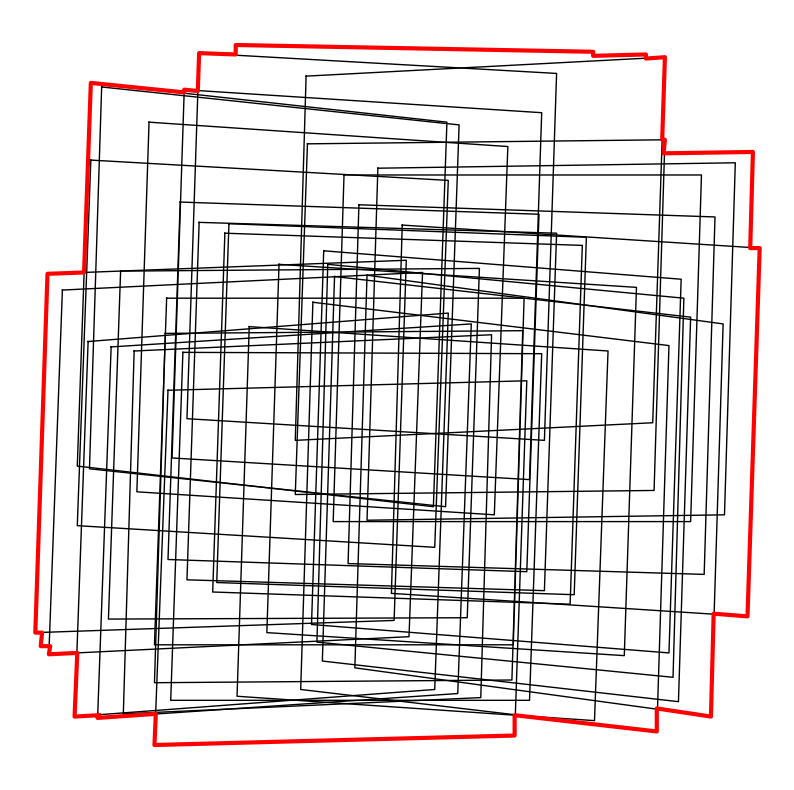

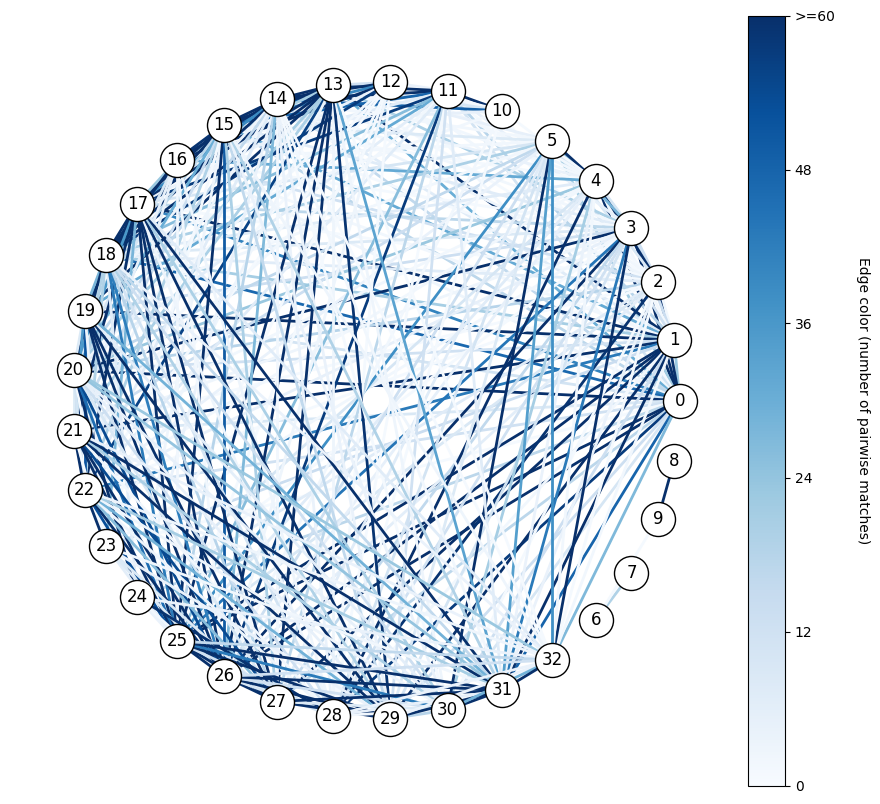

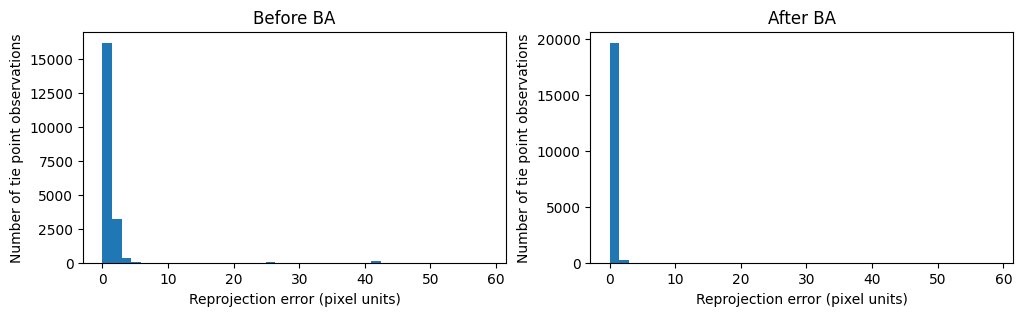

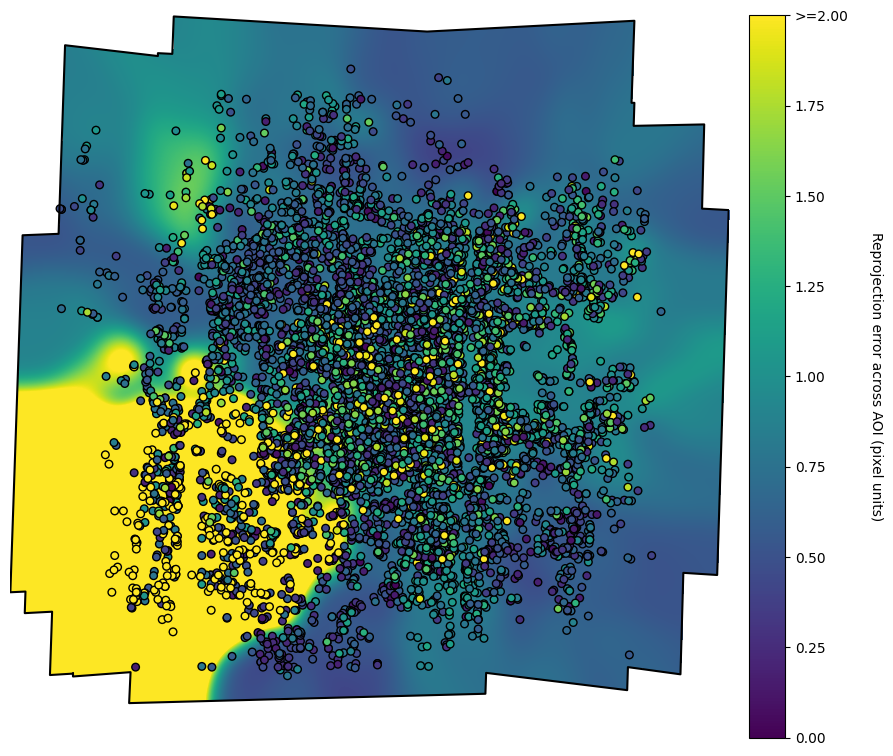

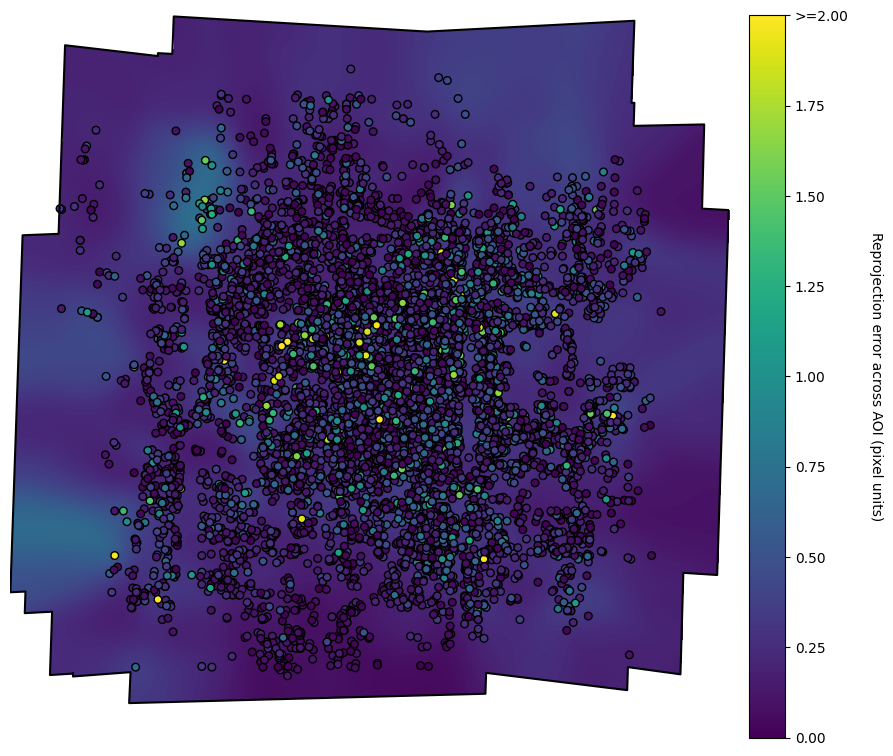

In [7]:
DATA_DIR = "/home/roger/sat-bundleadjust_github/DATA/data_ready_crops"
OUT_DIR = "/home/roger/sat-bundleadjust_github/LOGS/exhaustive_eval_crops"

sift = ["opencv", "s2p", "opencv", "s2p"]
matcher = ["flann", "lightglue", "flann", "lightglue"]
bestpairs = [False, False, True, True]

sift = ["s2p"]
matcher = ["lightglue"]
bestpairs = [True]


AOIs = ["OMA_042"]

n_ablations = len(sift)
for aoi_id in AOIs:
    for exp_i in range(n_ablations):

        sift_, matcher_, bestpairs_ = sift[exp_i], matcher[exp_i], bestpairs[exp_i]
        suffix_ =  "bestpairs" if bestpairs[exp_i] else "baseline"
        config = {
          "geotiff_dir": f"{DATA_DIR}/{aoi_id}/crops",
          "rpc_dir": f"{DATA_DIR}/{aoi_id}/rpcs",
          "rpc_src": "txt",
          "cam_model": "rpc",
          "output_dir": f"{OUT_DIR}/{aoi_id}/{sift_}-{matcher_}-{suffix_}",
          "ba_method": "ba_bruteforce",
          "FT_kp_max": 10000,
          "FT_sift_detection": sift_,
          "FT_sift_matching": matcher_,
          "FT_pair_ranking": bestpairs_,
        }
        
        print(f"\n    {aoi_id} ({exp_i}) Running {sift_}-{matcher_}-{suffix_}\n")
        bundle_adjust.main(config)

        # remove the heaviest files
        matches_dir = f"{config['output_dir']}/ba_bruteforce/matches"
        shutil.rmtree(matches_dir)

### Full images

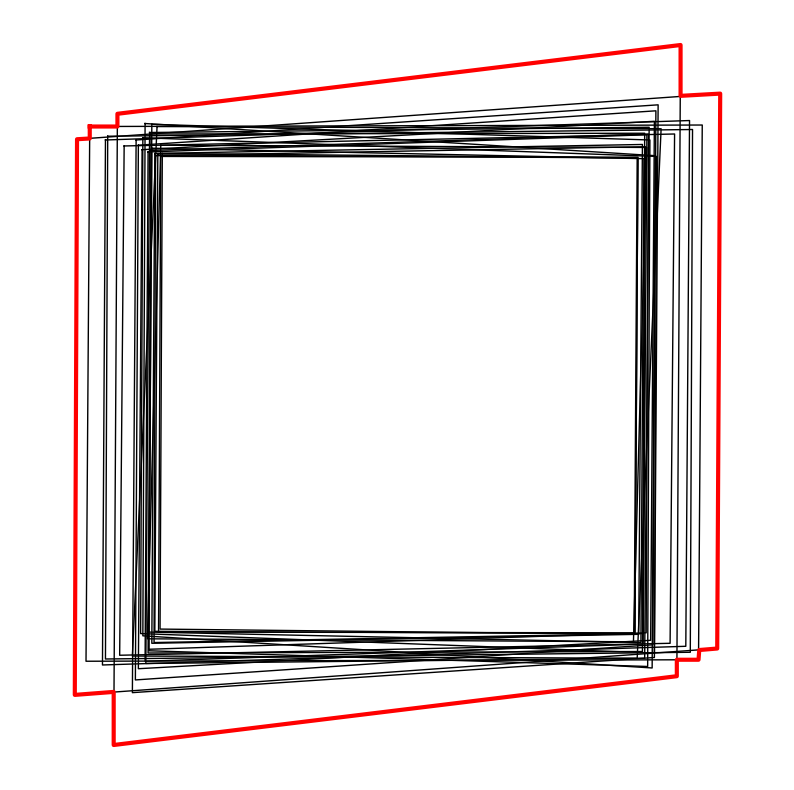

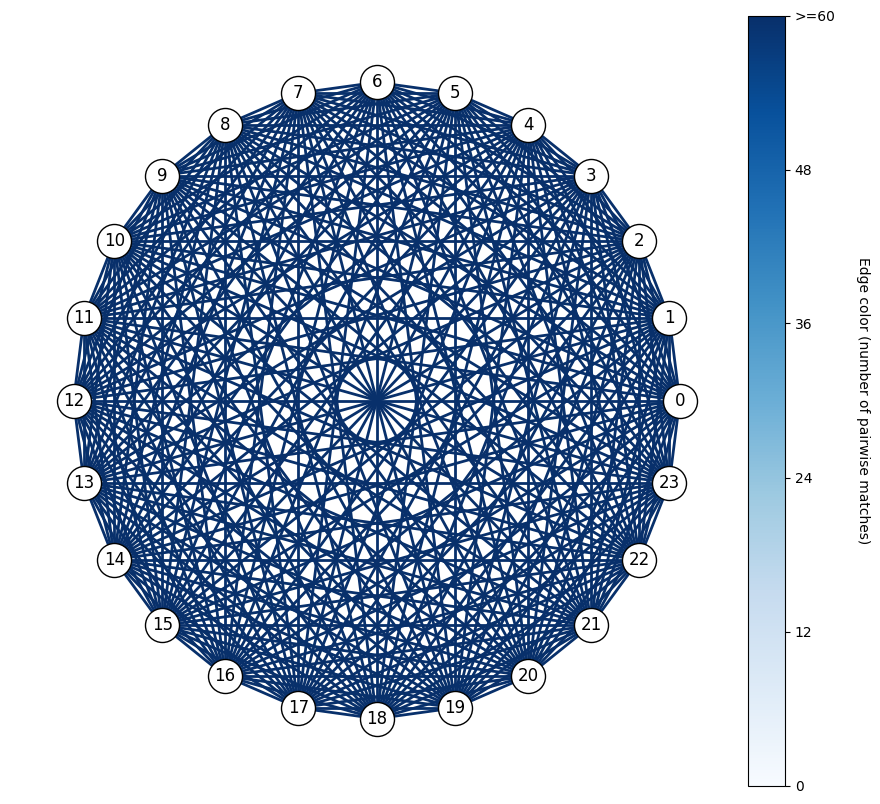

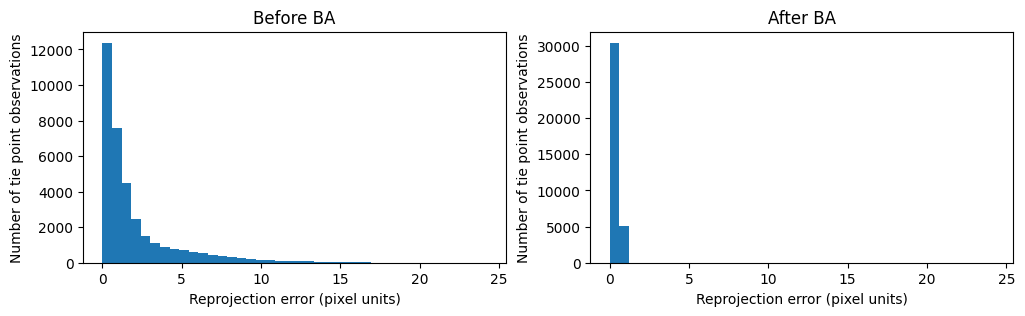

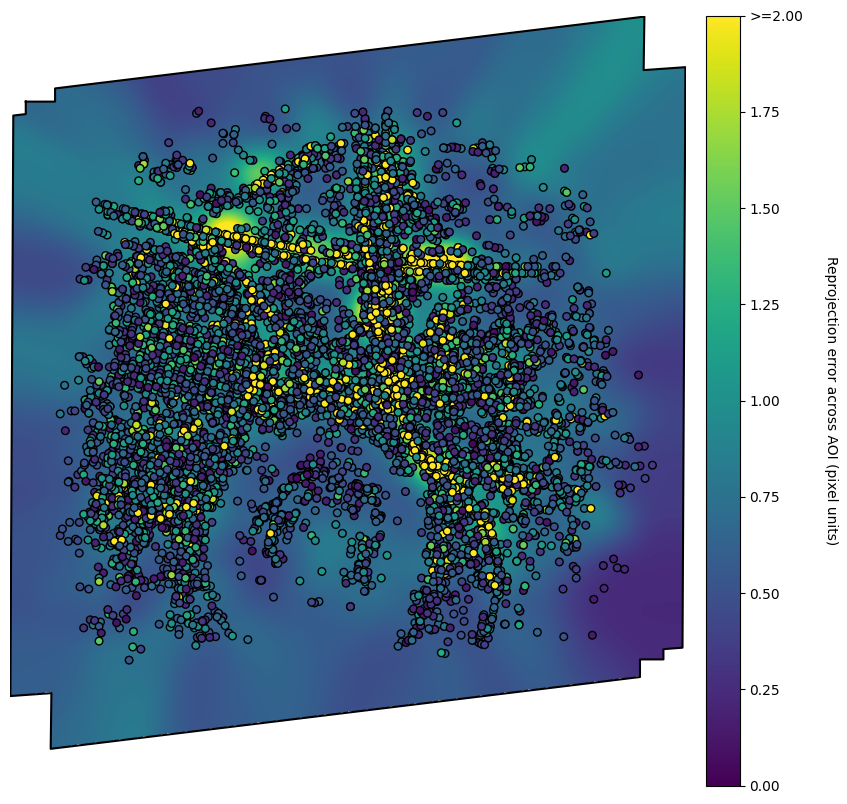

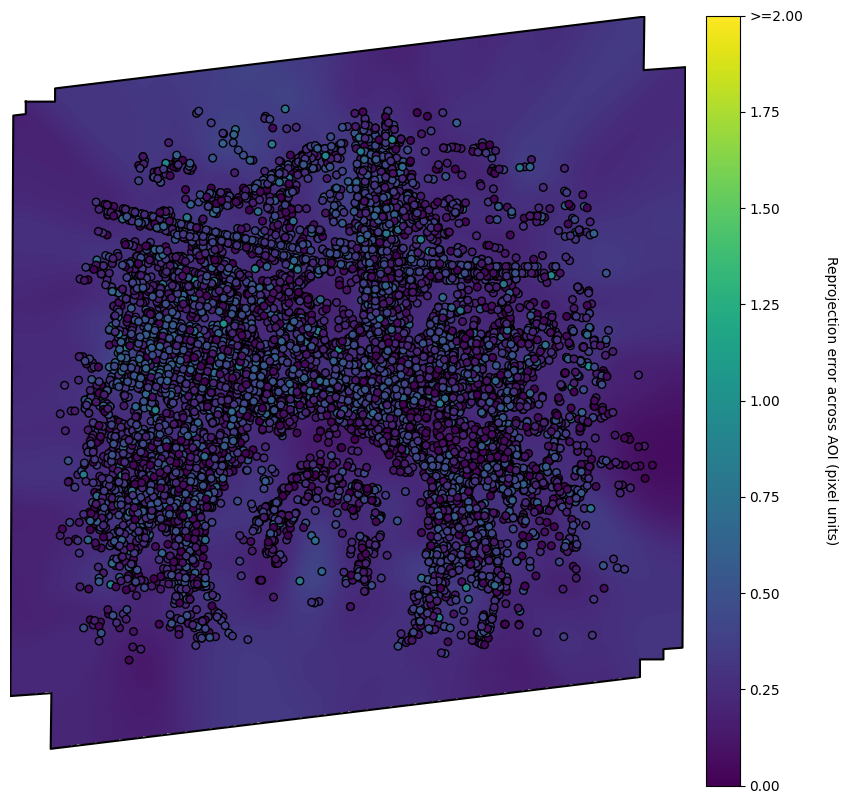

In [4]:
DATA_DIR = "/home/roger/sat-bundleadjust_github/DATA/data_ready_full/OMA"
DATA_DIR = "/home/roger/sat-bundleadjust_github/DATA/data_ready_full/JAX"
OUT_DIR = "/home/roger/sat-bundleadjust_github/LOGS/exhaustive_eval_full/OMA_newnew"
OUT_DIR = "/home/roger/sat-bundleadjust_github/LOGS/exhaustive_eval_full/JAX_debug"

sift = ["opencv", "opencv", "opencv", "opencv", "opencv", "opencv"]
matcher = ["lightglue", "lightglue", "lightglue_superpoint", "lightglue_superpoint", "flann", "flann"]
bestpairs = [False, True, False, True, False, True]

#AOIs = ["OMA_042", "OMA_355", "OMA_367", "OMA_381", "OMA_383", "OMA_389", "OMA_391"]

#AOIs = ["OMA_059", "OMA_132", "OMA_134", "OMA_144", "OMA_163", "OMA_172", "OMA_176", "OMA_203",
#         "OMA_211", "OMA_230", "OMA_244", "OMA_247", "OMA_248", "OMA_251", "OMA_258", "OMA_269",
#         "OMA_278", "OMA_281", "OMA_287", "OMA_315", "OMA_329", "OMA_331", "OMA_342", "OMA_353"]

AOIs = ["OMA_042", "OMA_059", "OMA_132", "OMA_134", "OMA_144", "OMA_163", "OMA_172", "OMA_176", "OMA_203", "OMA_211", "OMA_230", 
         "OMA_244", "OMA_247", "OMA_248", "OMA_251", "OMA_258", "OMA_269", "OMA_278", "OMA_281", "OMA_287", "OMA_315",
         "OMA_329", "OMA_331", "OMA_342", "OMA_353", "OMA_355", "OMA_367", "OMA_383", "OMA_389", "OMA_391"]

#AOIs = ["OMA_059"]

#AOIs = ["JAX_161", "JAX_168", "JAX_175", "JAX_178", "JAX_203", "JAX_204", "JAX_207", "JAX_264", "JAX_467", "JAX_474", "JAX_559"]

sift = ["opencv"]
matcher = ["lightglue_superpoint"]
bestpairs = [True]

AOIs = ["JAX_175"]

n_ablations = len(sift)
for aoi_id in AOIs:
    for exp_i in range(n_ablations):

        sift_, matcher_, bestpairs_ = sift[exp_i], matcher[exp_i], bestpairs[exp_i]
        suffix_ =  "bestpairs-K5" if bestpairs[exp_i] else "baseline"
        config = {
          "geotiff_dir": f"{DATA_DIR}/../../Track3-RGB-{'JAX' if 'JAX' in aoi_id else 'OMA'}/{aoi_id}",
          "rpc_dir": f"{DATA_DIR}/{aoi_id}/rpcs",
          "rpc_src": "txt",
          "cam_model": "rpc",
          "output_dir": f"{OUT_DIR}/{aoi_id}/{sift_ if matcher_ not in ['efficientloftr','lightglue_superpoint'] else ''}-{matcher_}-{suffix_}",
          "ba_method": "ba_bruteforce",
          "FT_kp_max": 10000,
          "FT_sift_detection": sift_,
          "FT_matcher": matcher_,
          "FT_pair_ranking": bestpairs_, 
          "FT_pair_ranking_K": 5
        }
        
        print(f"\n    {aoi_id} ({exp_i}) Running {sift_ if matcher_ not in ['efficientloftr','lightglue_superpoint'] else ''}-{matcher_}-{suffix_}\n")
        bundle_adjust.main(config)

        # remove the heaviest files
        matches_dir = f"{config['output_dir']}/ba_bruteforce/matches"
        shutil.rmtree(matches_dir)

### Debug

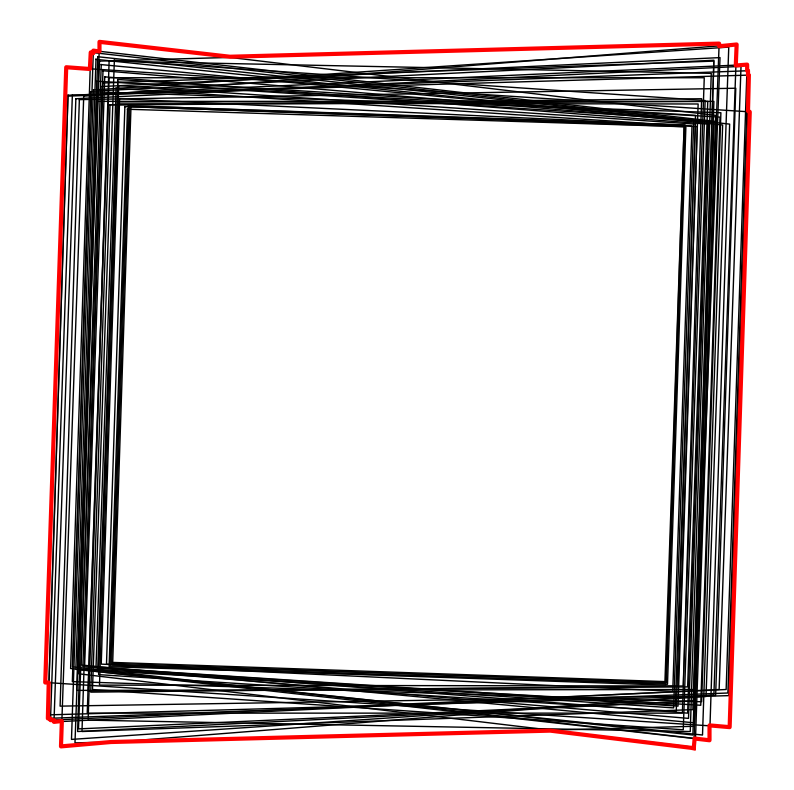

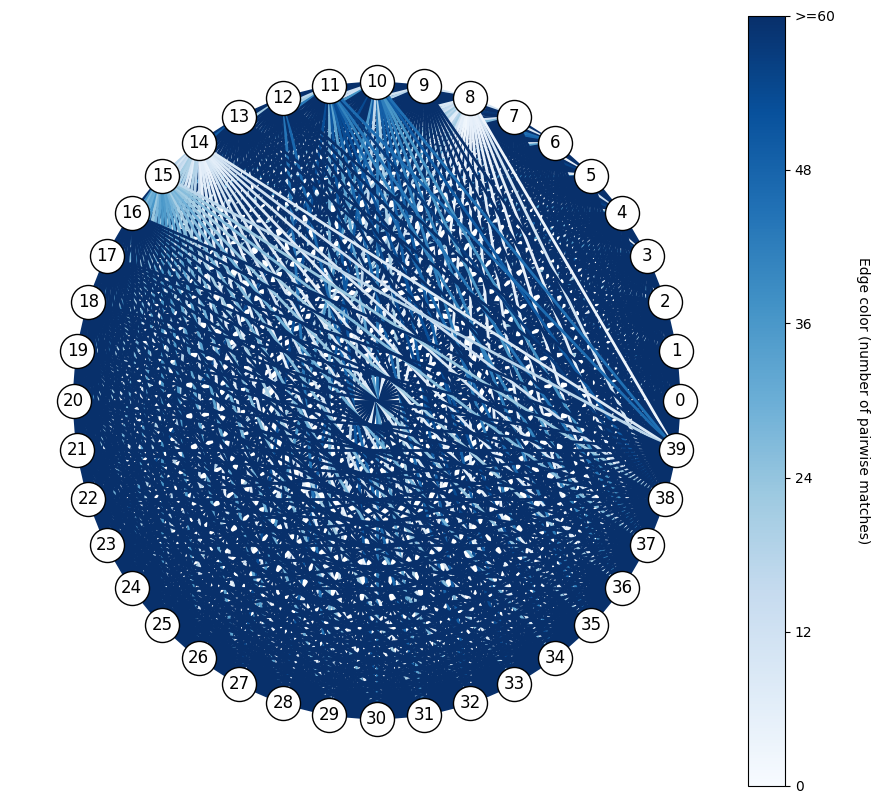

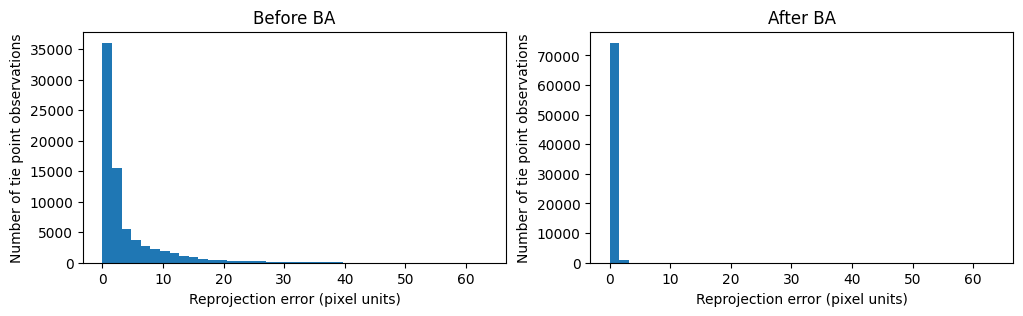

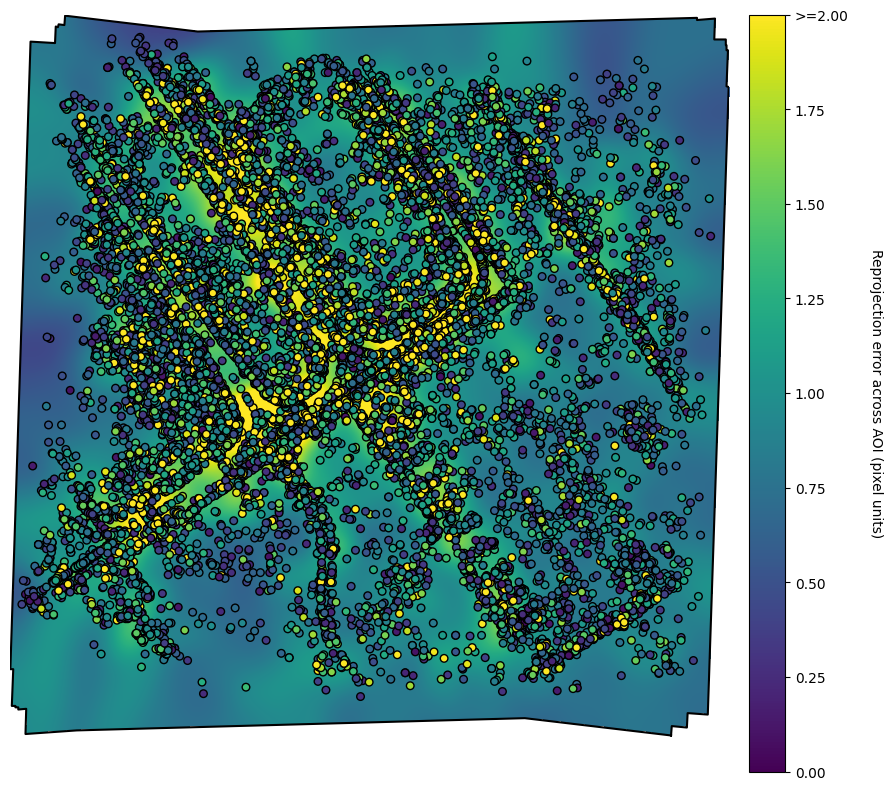

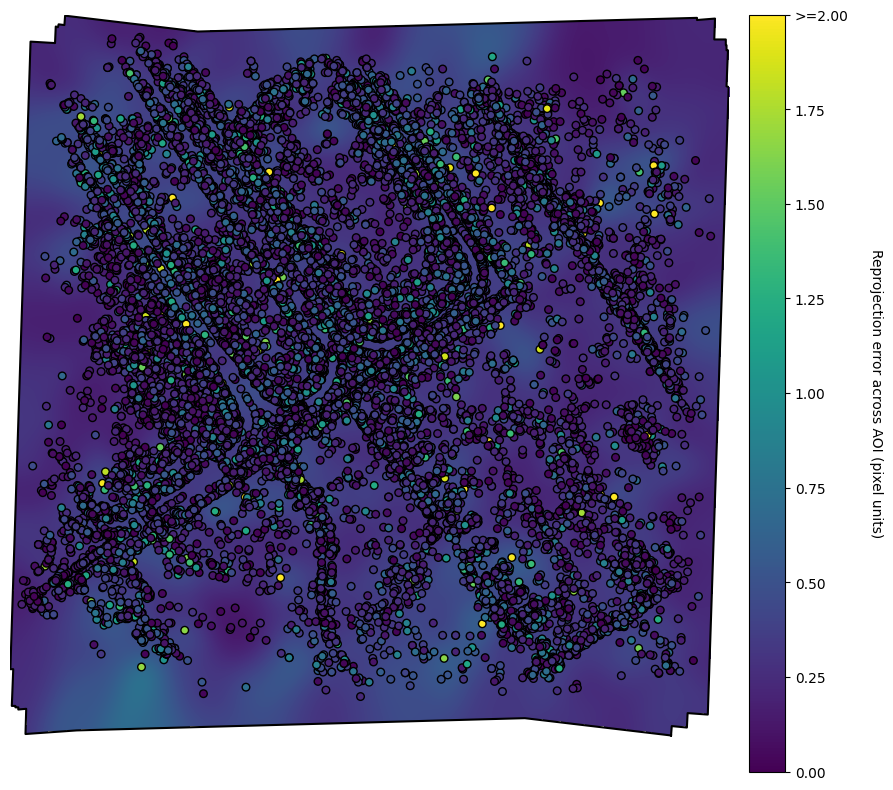

In [27]:
DATA_DIR = "/home/roger/sat-bundleadjust_github/DATA/data_ready_full"
OUT_DIR = "/home/roger/sat-bundleadjust_github/LOGS/debug_1"

#sift = ["opencv"]
#matcher = ["flann"]

sift = ["opencv"]
matcher = ["lightglue"]

bestpairs = [True]

#AOIs = ["OMA_042", "OMA_355", "OMA_367", "OMA_381", "OMA_383", "OMA_389", "OMA_391"]

AOIs = ["OMA_144"]

n_ablations = len(sift)
for aoi_id in AOIs:
    for exp_i in range(n_ablations):

        sift_, matcher_, bestpairs_ = sift[exp_i], matcher[exp_i], bestpairs[exp_i]
        suffix_ =  "bestpairs" if bestpairs[exp_i] else "baseline"
        config = {
          "geotiff_dir": f"{DATA_DIR}/../Track3-RGB/{aoi_id}",
          "rpc_dir": f"{DATA_DIR}/{aoi_id}/rpcs",
          "rpc_src": "txt",
          "cam_model": "rpc",
          "output_dir": f"{OUT_DIR}/{aoi_id}/{sift_}-{matcher_}-{suffix_}",
          "ba_method": "ba_bruteforce",
          "FT_kp_max": 10000,
          "FT_sift_detection": sift_,
          "FT_sift_matching": matcher_,
          "FT_pair_ranking": bestpairs_,
        }
        
        print(f"\n    {aoi_id} ({exp_i}) Running {sift_}-{matcher_}-{suffix_}\n")
        bundle_adjust.main(config)

        # remove the heaviest files
        matches_dir = f"{config['output_dir']}/ba_bruteforce/matches"
        shutil.rmtree(matches_dir)